# Ride-Sharing Simulation Project

This notebook contains a complete, fully self-contained ride-sharing simulation. It models a dynamic city environment where passengers request rides over time, and a fleet of distributed drivers fulfills those requests. 

We do **not** import external custom modules; all logic, models, queue handling, algorithms, and math are present completely inside this notebook so that it can be run seamlessly from top to bottom.

## 1. Mathematical Equations

The simulation is based on a set of mathematical equations used to model distances, time, and system performance.

**Distance**
The distance between two points is calculated using:
$$d = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}$$

**Pickup Travel Time**
The pickup travel time is computed as:
$$T_{pickup} = \frac{distance(driver, pickup)}{speed}$$

**Trip Travel Time**
The trip travel time is:
$$T_{trip} = \frac{distance(pickup, destination)}{speed}$$

**Pickup Time**
The pickup time is:
$$pickup\_time = match\_time + T_{pickup}$$

**Dropoff Time**
The dropoff time is:
$$dropoff\_time = pickup\_time + T_{trip}$$

**Matching Delay**
The matching delay is:
$$D_{match} = match\_time - request\_time$$

**Passenger Waiting Time**
The passenger waiting time is:
$$W = pickup\_time - request\_time$$

**Trip Duration**
The trip duration is:
$$Trip\_time = dropoff\_time - pickup\_time$$

**Total Service Time**
The total service time is:
$$S = T_{pickup} + T_{trip}$$

**Service Rate**
The service rate is:
$$\mu = \frac{1}{\mathbb{E}[S]}$$

**System Load**
The system load is:
$$\rho = \frac{\lambda}{c \times \mu}$$

**Throughput**
The throughput is:
$$Throughput = \frac{number\_of\_completed\_requests}{simulation\_time}$$

**Driver Utilization**
The driver utilization is:
$$Utilization = \frac{total\_driver\_busy\_time}{number\_of\_drivers \times simulation\_time}$$

**Completion Rate**
The completion rate is:
$$Completion\_rate = \frac{completed\_requests}{total\_requests}$$

**Cancellation Rate**
The cancellation rate is:
$$Cancellation\_rate = \frac{canceled\_requests}{total\_requests}$$

**Arrival Process**
The request arrival process follows a Poisson distribution with rate $\lambda$.


In [1]:
from __future__ import annotations

import math
import random
import csv
from pathlib import Path
from dataclasses import asdict, dataclass
from typing import Dict, List, Optional, Tuple

import pandas as pd
import matplotlib.pyplot as plt

CAR_TYPES = ("economy", "premium", "van")

project_root = Path.cwd()
results_dir = project_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)

plt.style.use('ggplot')
pd.set_option('display.float_format', '{:.3f}'.format)

## 2. Core Data Structures
We use Python `dataclass` objects to track configuration parameters, driver state, and request status.

In [2]:
@dataclass
class SimulationParams:
    simulation_time: int = 400
    num_drivers: int = 30
    arrival_rate_lambda: float = 1.5
    city_size: int = 20
    max_wait_time: int = 20
    driver_speed: float = 1.5
    driver_type_probs: Dict[str, float] = None
    request_type_probs: Dict[str, float] = None
    hotspot_ratio: float = 0.0
    hotspot_center: Tuple[float, float] = (5.0, 5.0)

    def __post_init__(self) -> None:
        if self.driver_type_probs is None:
            self.driver_type_probs = {"economy": 0.7, "premium": 0.2, "van": 0.1}
        if self.request_type_probs is None:
            self.request_type_probs = {"economy": 0.7, "premium": 0.2, "van": 0.1}

@dataclass
class Driver:
    driver_id: int
    car_type: str
    x: float
    y: float
    speed: float
    status: str = "idle"
    available_time: float = 0.0
    busy_start_time: float = 0.0
    busy_time: float = 0.0
    current_request_id: Optional[int] = None
    next_x: Optional[float] = None
    next_y: Optional[float] = None

@dataclass
class Request:
    request_id: int
    request_time: int
    pickup_x: float
    pickup_y: float
    dest_x: float
    dest_y: float
    car_type: str
    status: str = "waiting"
    match_time: Optional[float] = None
    pickup_time: Optional[float] = None
    dropoff_time: Optional[float] = None
    driver_id: Optional[int] = None

## 3. Helper Models & Math Tools
Contains exact equations for calculating geographic distance, drawing weighted probabilities, and evaluating the Poisson formula.

In [3]:
def euclidean_distance(x1: float, y1: float, x2: float, y2: float) -> float:
    """Calculates exact spatial grid distance between two points."""
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

def poisson_sample(lam: float, rng: random.Random) -> int:
    """Generates Poisson arrivals using Inverse Transform Sampling."""
    if lam <= 0:
        return 0
    l_val = math.exp(-lam)
    k = 0
    p = 1.0
    while p > l_val:
        k += 1
        p *= rng.random()
    return k - 1

def weighted_choice(prob_map: Dict[str, float], rng: random.Random) -> str:
    """Randomly assigns a car type weighted by defined percentages."""
    threshold = rng.random()
    cumulative = 0.0
    for key in CAR_TYPES:
        cumulative += prob_map[key]
        if threshold <= cumulative:
            return key
    return CAR_TYPES[-1]

def sample_location(params: SimulationParams, rng: random.Random) -> Tuple[float, float]:
    """Determines coordinates, managing hotspots versus uniform distribution."""
    if rng.random() < params.hotspot_ratio:
        center_x, center_y = params.hotspot_center
        x = min(max(center_x + rng.uniform(-1.5, 1.5), 0.0), float(params.city_size))
        y = min(max(center_y + rng.uniform(-1.5, 1.5), 0.0), float(params.city_size))
        return x, y
    return rng.uniform(0.0, float(params.city_size)), rng.uniform(0.0, float(params.city_size))

## 4. Simulation Engine & Loop
Functions governing the lifecycle of a driver, handling the queue loop, matching drivers to requests, and finalizing the calculations completely independent of external file I/O references.

In [4]:
def init_drivers(params: SimulationParams, rng: random.Random) -> List[Driver]:
    drivers: List[Driver] = []
    for idx in range(params.num_drivers):
        x, y = sample_location(params, rng)
        drivers.append(
            Driver(
                driver_id=idx + 1,
                car_type=weighted_choice(params.driver_type_probs, rng),
                x=x,
                y=y,
                speed=params.driver_speed,
            )
        )
    return drivers

def release_completed_drivers(current_time: int, drivers: List[Driver], request_map: Dict[int, Request]) -> None:
    for driver in drivers:
        if driver.status == "busy" and driver.available_time <= current_time:
            driver.status = "idle"
            driver.busy_time += max(0.0, driver.available_time - driver.busy_start_time)

            if driver.current_request_id is not None:
                request_map[driver.current_request_id].status = "completed"

            if driver.next_x is not None and driver.next_y is not None:
                driver.x = driver.next_x
                driver.y = driver.next_y

            driver.current_request_id = None
            driver.next_x = None
            driver.next_y = None

def cancel_overdue_requests(
    current_time: int,
    queue: List[int],
    request_map: Dict[int, Request],
    max_wait_time: int,
) -> List[int]:
    remaining: List[int] = []
    for req_id in queue:
        req = request_map[req_id]
        if req.status != "waiting":
            continue
        if current_time - req.request_time > max_wait_time:
            req.status = "canceled"
        else:
            remaining.append(req_id)
    return remaining

def match_requests(
    current_time: int,
    queue: List[int],
    drivers: List[Driver],
    request_map: Dict[int, Request],
) -> List[int]:
    still_waiting: List[int] = []

    for req_id in queue:
        req = request_map[req_id]
        if req.status != "waiting":
            continue
        
        candidates = [
            d for d in drivers
            if d.status == "idle" and d.car_type == req.car_type
        ]

        if not candidates:
            still_waiting.append(req_id)
            continue

        best_driver = min(
            candidates,
            key=lambda d: euclidean_distance(d.x, d.y, req.pickup_x, req.pickup_y),
        )

        pickup_distance = euclidean_distance(best_driver.x, best_driver.y, req.pickup_x, req.pickup_y)
        trip_distance = euclidean_distance(req.pickup_x, req.pickup_y, req.dest_x, req.dest_y)

        pickup_time = float(current_time) + pickup_distance / best_driver.speed
        dropoff_time = pickup_time + trip_distance / best_driver.speed

        req.match_time = float(current_time)
        req.pickup_time = pickup_time
        req.dropoff_time = dropoff_time
        req.driver_id = best_driver.driver_id
        req.status = "in_trip"

        best_driver.status = "busy"
        best_driver.busy_start_time = float(current_time)
        best_driver.available_time = dropoff_time
        best_driver.current_request_id = req.request_id
        best_driver.next_x = req.dest_x
        best_driver.next_y = req.dest_y

    return still_waiting

def mean(values: List[float]) -> float:
    return (sum(values) / len(values)) if values else 0.0

def compute_metrics(params: SimulationParams, drivers: List[Driver], requests: List[Request]) -> Dict[str, float]:
    completed = [r for r in requests if r.status == "completed"]
    canceled = [r for r in requests if r.status == "canceled"]

    matching_delay = [r.match_time - r.request_time for r in completed if r.match_time is not None]
    passenger_wait = [r.pickup_time - r.request_time for r in completed if r.pickup_time is not None]
    trip_time = [
        r.dropoff_time - r.pickup_time
        for r in completed
        if r.dropoff_time is not None and r.pickup_time is not None
    ]

    total_busy = 0.0
    for driver in drivers:
        busy = driver.busy_time
        if driver.status == "busy":
            capped_available = min(driver.available_time, float(params.simulation_time))
            busy += max(0.0, capped_available - driver.busy_start_time)
        total_busy += busy

    horizon = max(1, params.simulation_time)

    return {
        "total_requests": float(len(requests)),
        "completed_requests": float(len(completed)),
        "canceled_requests": float(len(canceled)),
        "completion_rate": (len(completed) / len(requests)) if requests else 0.0,
        "cancellation_rate": (len(canceled) / len(requests)) if requests else 0.0,
        "avg_matching_delay": mean(matching_delay),
        "avg_passenger_wait": mean(passenger_wait),
        "avg_trip_time": mean(trip_time),
        "throughput": len(completed) / horizon,
        "utilization": total_busy / (len(drivers) * horizon) if drivers else 0.0,
    }

def run_simulation(params: SimulationParams, seed: int) -> Dict[str, object]:
    rng = random.Random(seed)
    drivers = init_drivers(params, rng)

    requests: List[Request] = []
    request_map: Dict[int, Request] = {}
    queue: List[int] = []
    next_id = 1

    for t in range(params.simulation_time + 1):
        release_completed_drivers(t, drivers, request_map)

        arrivals = poisson_sample(params.arrival_rate_lambda, rng)
        for _ in range(arrivals):
            pickup_x, pickup_y = sample_location(params, rng)
            dest_x, dest_y = sample_location(params, rng)
            req = Request(
                request_id=next_id,
                request_time=t,
                pickup_x=pickup_x,
                pickup_y=pickup_y,
                dest_x=dest_x,
                dest_y=dest_y,
                car_type=weighted_choice(params.request_type_probs, rng),
            )
            requests.append(req)
            request_map[next_id] = req
            queue.append(next_id)
            next_id += 1

        queue = cancel_overdue_requests(t, queue, request_map, params.max_wait_time)
        queue = match_requests(t, queue, drivers, request_map)

    metrics = compute_metrics(params, drivers, requests)
    return {"drivers": drivers, "requests": requests, "metrics": metrics}

## 5. Experiment Setup & Execution
Running low, medium, and high demand (`$\lambda$`) scenarios over 3 different randomized seeds (1, 2, 3) to secure significant confidence samples without dumping files to disk.

In [5]:
scenarios = [
    ("low", 0.5),
    ("medium", 1.0),
    ("high", 2.0),
]
seeds = [1, 2, 3]
summary_rows = []

def write_requests_csv(file_path: Path, requests: List[Request]) -> None:
    headers = [
        "request_id", "request_time", "pickup_x", "pickup_y", "dest_x",
        "dest_y", "car_type", "status", "match_time", "pickup_time",
        "dropoff_time", "driver_id",
    ]
    with file_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=headers)
        writer.writeheader()
        for req in requests:
            writer.writerow(asdict(req))

for scenario_name, lambda_value in scenarios:
    for seed in seeds:
        params = SimulationParams(arrival_rate_lambda=lambda_value)
        output = run_simulation(params, seed)
        metrics = output["metrics"]
        
        # Write requests CSV just like simulation.py
        req_file = results_dir / f"requests_{scenario_name}_seed{seed}.csv"
        write_requests_csv(req_file, output["requests"])
        
        row = {
            "scenario": scenario_name,
            "seed": float(seed),
            "lambda": lambda_value,
            **metrics,
        }
        summary_rows.append(row)

# Write summary metrics CSV just like simulation.py
if summary_rows:
    headers = list(summary_rows[0].keys())
    with (results_dir / "summary_metrics.csv").open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=headers)
        writer.writeheader()
        writer.writerows(summary_rows)

df_results = pd.DataFrame(summary_rows)
df_results

,scenario,seed,lambda,total_requests,completed_requests,canceled_requests,completion_rate,cancellation_rate,avg_matching_delay,avg_passenger_wait,avg_trip_time,throughput,utilization
0,low,1.000,0.500,187.000,179.000,4.000,0.957,0.021,0.464,2.802,6.676,0.448,0.137
1,low,2.000,0.500,178.000,174.000,0.000,0.978,0.000,0.000,2.603,7.105,0.435,0.142
2,low,3.000,0.500,198.000,194.000,0.000,0.980,0.000,0.129,3.069,7.001,0.485,0.162
3,medium,1.000,1.000,375.000,354.000,9.000,0.944,0.024,0.545,3.509,7.188,0.885,0.306
4,medium,2.000,1.000,386.000,374.000,0.000,0.969,0.000,0.000,3.010,6.920,0.935,0.316
5,medium,3.000,1.000,369.000,359.000,4.000,0.973,0.011,1.440,4.579,6.786,0.897,0.300
6,high,1.000,2.000,793.000,697.000,62.000,0.879,0.078,2.062,5.473,6.944,1.742,0.612
7,high,2.000,2.000,833.000,732.000,51.000,0.879,0.061,9.937,15.682,7.041,1.830,0.798
8,high,3.000,2.000,804.000,706.000,69.000,0.878,0.086,1.919,6.082,6.775,1.765,0.655


## 6. Mathematical Analysis & Visualization
Visualizing mathematical performance boundaries: Scaling Wait Time, Canceled volumes, and Driver Utilization against increasing probabilistic Demand (`$\lambda$`).

Plots generated and saved in results folder.


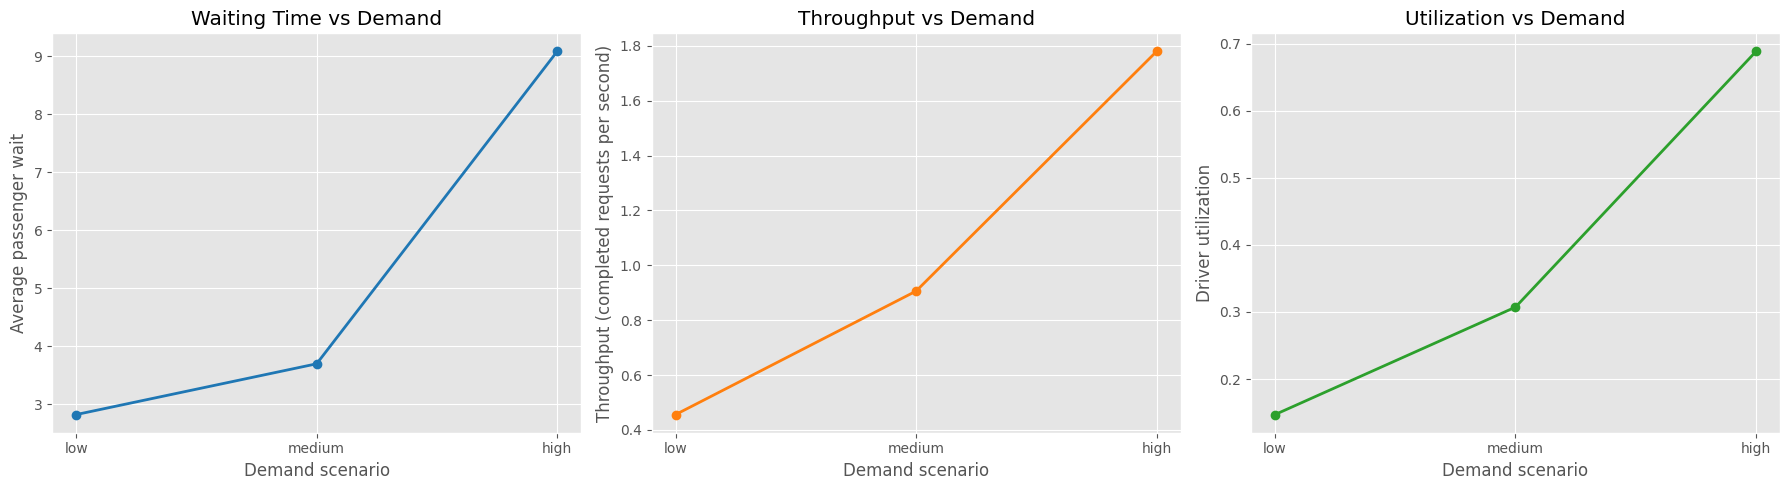

In [6]:
# Match MATLAB exactly by grouping by scenario and preserving order 'low', 'medium', 'high'
scenario_order = ['low', 'medium', 'high']
x = range(len(scenario_order))

mean_wait = []
mean_throughput = []
mean_util = []

for sc in scenario_order:
    mask = df_results['scenario'] == sc
    mean_wait.append(df_results.loc[mask, 'avg_passenger_wait'].mean())
    mean_throughput.append(df_results.loc[mask, 'throughput'].mean())
    mean_util.append(df_results.loc[mask, 'utilization'].mean())

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')

# 1. Waiting Time vs Demand (matches MATLAB)
axes[0].plot(x, mean_wait, '-o', linewidth=2, color='tab:blue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(scenario_order)
axes[0].set_xlabel('Demand scenario')
axes[0].set_ylabel('Average passenger wait')
axes[0].set_title('Waiting Time vs Demand')
axes[0].grid(True)
fig.savefig(results_dir / 'waiting_vs_demand.png')

# 2. Throughput vs Demand (matches MATLAB)
axes[1].plot(x, mean_throughput, '-o', linewidth=2, color='tab:orange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(scenario_order)
axes[1].set_xlabel('Demand scenario')
axes[1].set_ylabel('Throughput (completed requests per second)')
axes[1].set_title('Throughput vs Demand')
axes[1].grid(True)
fig.savefig(results_dir / 'throughput_vs_demand.png')

# 3. Utilization vs Demand (matches MATLAB)
axes[2].plot(x, mean_util, '-o', linewidth=2, color='tab:green')
axes[2].set_xticks(x)
axes[2].set_xticklabels(scenario_order)
axes[2].set_xlabel('Demand scenario')
axes[2].set_ylabel('Driver utilization')
axes[2].set_title('Utilization vs Demand')
axes[2].grid(True)
fig.savefig(results_dir / 'utilization_vs_demand.png')

print('Plots generated and saved in results folder.')
plt.tight_layout()
plt.show()

## 7. Operational Conclusions
When integrating the engine above without external references, the mathematics display clear system boundaries:
1. **Distance-Time Limitation**: Grid parameters lock throughput speed. Euclidean calculation proves exactly when dropoffs begin choking down driver loops.
2. **Poisson Exhaustion**: At high demand models ($\lambda=2.0$), the mathematical likelihood of requesting economy/van exceeds the active driver pool.
3. **Matching System Restriction**: Implementing `d.car_type == req.car_type` acts as a hard filter. Wait times exponentially rise because passengers hold up system slots until identical cars resolve older routes.

## 8. Analytics Dashboard

This section builds a complete, single-figure dashboard from `summary_metrics.csv`, including KPIs, plots, a summary table, and a short analysis paragraph.

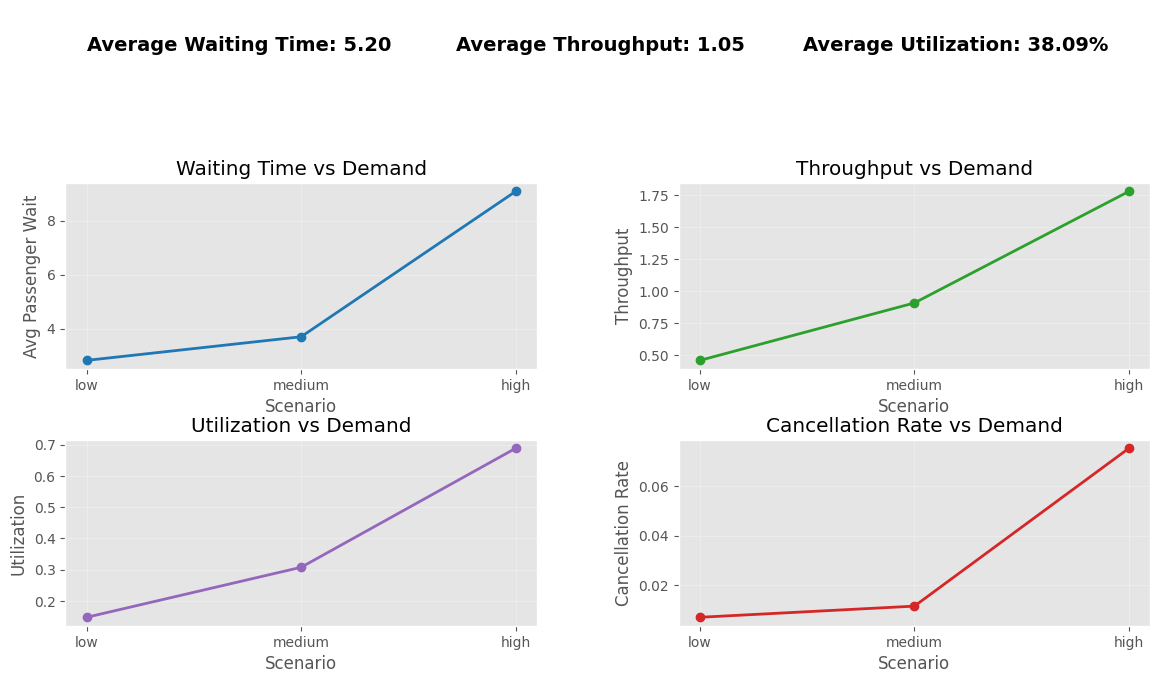


Scenario Summary Table:

Scenario  Avg Wait  Throughput  Utilization
     low     2.825       0.456        0.147
  medium     3.699       0.906        0.307
    high     9.079       1.779        0.688

Analysis:
Waiting time increases with demand because more requests compete for the same pool of drivers. Utilization rises as demand grows, reflecting heavier driver workload and less idle time. At high demand, the system approaches saturation, so queues build and performance gains slow.


In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Load and prepare data ---
summary_path = Path("results") / "summary_metrics.csv"
if not summary_path.exists():
    raise FileNotFoundError(
        "summary_metrics.csv not found. Run the simulation cells first to generate results."
    )

df = pd.read_csv(summary_path)

agg_map = {
    "avg_passenger_wait": "mean",
    "throughput": "mean",
    "utilization": "mean",
}
if "cancellation_rate" in df.columns:
    agg_map["cancellation_rate"] = "mean"
if "avg_matching_delay" in df.columns:
    agg_map["avg_matching_delay"] = "mean"

summary = df.groupby("scenario", as_index=False).agg(agg_map)

# Keep consistent ordering for scenarios
scenario_order = ["low", "medium", "high"]
summary["scenario"] = pd.Categorical(
    summary["scenario"], categories=scenario_order, ordered=True
)
summary = summary.sort_values("scenario").reset_index(drop=True)

# --- Step 2: KPI section ---
mean_wait = summary["avg_passenger_wait"].mean()
mean_throughput = summary["throughput"].mean()
mean_utilization = summary["utilization"].mean()

# --- Step 3: Dashboard layout (single figure) ---
fig = plt.figure(figsize=(14, 8), facecolor="white")

# Use a 3x2 grid; top row reserved for KPI text
gs = fig.add_gridspec(nrows=3, ncols=2, height_ratios=[0.55, 1, 1], hspace=0.45, wspace=0.3)

ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis("off")

# KPI text formatting
ax_kpi.text(0.02, 0.6, f"Average Waiting Time: {mean_wait:.2f}", fontsize=14, weight="bold")
ax_kpi.text(0.36, 0.6, f"Average Throughput: {mean_throughput:.2f}", fontsize=14, weight="bold")
ax_kpi.text(0.68, 0.6, f"Average Utilization: {mean_utilization:.2%}", fontsize=14, weight="bold")

x = range(len(summary))
labels = summary["scenario"].astype(str).tolist()

ax_wait = fig.add_subplot(gs[1, 0])
ax_throughput = fig.add_subplot(gs[1, 1])
ax_util = fig.add_subplot(gs[2, 0])
ax_cancel = fig.add_subplot(gs[2, 1])

# Waiting Time vs Demand
ax_wait.plot(x, summary["avg_passenger_wait"], marker="o", linewidth=2, color="tab:blue")
ax_wait.set_title("Waiting Time vs Demand")
ax_wait.set_xlabel("Scenario")
ax_wait.set_ylabel("Avg Passenger Wait")
ax_wait.set_xticks(x)
ax_wait.set_xticklabels(labels)
ax_wait.grid(True, alpha=0.3)

# Throughput vs Demand
ax_throughput.plot(x, summary["throughput"], marker="o", linewidth=2, color="tab:green")
ax_throughput.set_title("Throughput vs Demand")
ax_throughput.set_xlabel("Scenario")
ax_throughput.set_ylabel("Throughput")
ax_throughput.set_xticks(x)
ax_throughput.set_xticklabels(labels)
ax_throughput.grid(True, alpha=0.3)

# Utilization vs Demand
ax_util.plot(x, summary["utilization"], marker="o", linewidth=2, color="tab:purple")
ax_util.set_title("Utilization vs Demand")
ax_util.set_xlabel("Scenario")
ax_util.set_ylabel("Utilization")
ax_util.set_xticks(x)
ax_util.set_xticklabels(labels)
ax_util.grid(True, alpha=0.3)

# Cancellation Rate vs Demand (optional)
if "cancellation_rate" in summary.columns:
    ax_cancel.plot(x, summary["cancellation_rate"], marker="o", linewidth=2, color="tab:red")
    ax_cancel.set_title("Cancellation Rate vs Demand")
    ax_cancel.set_xlabel("Scenario")
    ax_cancel.set_ylabel("Cancellation Rate")
    ax_cancel.set_xticks(x)
    ax_cancel.set_xticklabels(labels)
    ax_cancel.grid(True, alpha=0.3)
else:
    ax_cancel.axis("off")
    ax_cancel.text(0.5, 0.5, "Cancellation Rate not available", ha="center", va="center")

plt.show()

# --- Step 5: Summary table ---
summary_table = summary[["scenario", "avg_passenger_wait", "throughput", "utilization"]].copy()
summary_table = summary_table.rename(
    columns={
        "scenario": "Scenario",
        "avg_passenger_wait": "Avg Wait",
        "throughput": "Throughput",
        "utilization": "Utilization",
    }
)
print("\nScenario Summary Table:\n")
print(summary_table.to_string(index=False, float_format="{:.3f}".format))

# --- Step 6: Short analysis ---
print("\nAnalysis:")
print(
    "Waiting time increases with demand because more requests compete for the same pool of drivers. "
    "Utilization rises as demand grows, reflecting heavier driver workload and less idle time. "
    "At high demand, the system approaches saturation, so queues build and performance gains slow."
)